# Extension pilots, explained

Plots and plain-language explanations of the four extension pilots we ran locally on the trained models' outputs. Everything here loads committed files (no GPU, no torch needed), so anyone on the team can re-run it.

**The story so far, in three sentences.** We reproduced the COSETTE/MARIUS paper (arXiv:2508.14910) and found its 'generative model is competitive with the traditional baseline on small data' claim does not hold (SASRec++ R@10 9.04 vs MARIUS 8.26 on Beauty). We then measured what the paper never did: diversity, catalog coverage, and popularity bias, and found a surprise: the generative model is MORE diverse on the denser dataset (Beauty) but COLLAPSES on the sparser one (Sports), never recommending 61% of the catalog. The four pilots below dig into why that happens and what could fix or exploit it.

| Pilot | Question | Status |
|---|---|---|
| Audit | How do the two models differ beyond accuracy? | done |
| REACH | WHY does MARIUS collapse on Sports? | done (mechanism found) |
| MBR | Can re-ranking the beam by consensus help? | lower-bound done |
| Conformal | Can we give coverage guarantees + uncertainty? | feasibility done |
| FUSE | Is the sum-fusion an architectural mistake? | code ready, training on Snellius |

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / 'scripts' / 'extensions' / 'beyond_accuracy.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
from scripts.extensions import beyond_accuracy as ba
from scripts.extensions.compute_beyond_accuracy import load_support, load_model_recs

EXT = REPO / 'reports' / 'extensions'
CATS = ['Beauty', 'Sports_and_Outdoors']
SHORT = {'Beauty': 'Beauty', 'Sports_and_Outdoors': 'Sports'}
SEEDS = [42, 43, 44]
COL = {'marius': '#d62728', 'sasrec': '#1f77b4'}
plt.rcParams['figure.dpi'] = 110
print('repo:', REPO)

repo: /home/stas/Desktop/University/RECSYS/rec_sys_cosette_marius


## 1. The audit: same models, opposite behavior on two datasets

Both models produce a ranked top-10 for every test user. We measure, over all users: **coverage** (what fraction of the catalog ever gets recommended to anyone), **Gini** (how unequally recommendations concentrate on a few items; higher = more concentrated), and the **popularity-decile exposure profile** (how the recommendation 'budget' is spread from the rarest 10% of items, D1, to the most popular 10%, D10).

Read the plots below left to right: on Beauty, MARIUS (red) pushes the most-popular decile LESS than SASRec++ (blue) and spreads more to mid-popularity items: the generative model looks healthier. On Sports the same architecture flips: coverage crashes to 39% and concentration is HIGHER than the baseline. One architecture, two opposite diversity profiles, decided by data density.

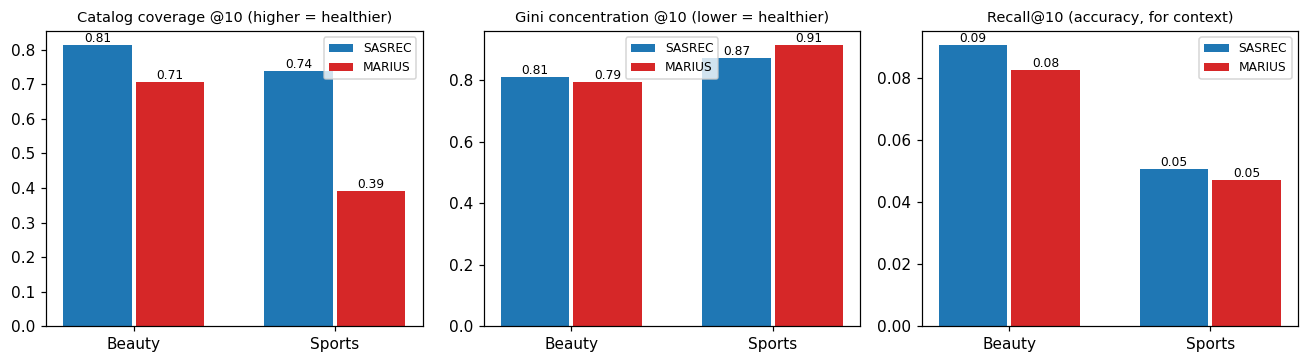

In [2]:
# Coverage and Gini at k=10 from the committed audit CSVs.
audit = pd.concat([pd.read_csv(EXT / f'beyond_accuracy_{c}.csv') for c in CATS])
a10 = audit[audit.k == 10].set_index(['category', 'model'])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, metric, title, better in zip(
        axes, ['coverage_mean', 'gini_mean', 'recall_mean'],
        ['Catalog coverage @10 (higher = healthier)',
         'Gini concentration @10 (lower = healthier)',
         'Recall@10 (accuracy, for context)'], [1, -1, 1]):
    x = np.arange(len(CATS))
    for i, m in enumerate(['sasrec', 'marius']):
        vals = [a10.loc[(c, m), metric] for c in CATS]
        ax.bar(x + (i - 0.5) * 0.36, vals, 0.34, label=m.upper(), color=COL[m])
        for xi, v in zip(x, vals):
            ax.text(xi + (i - 0.5) * 0.36, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([SHORT[c] for c in CATS])
    ax.set_title(title, fontsize=9.5); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

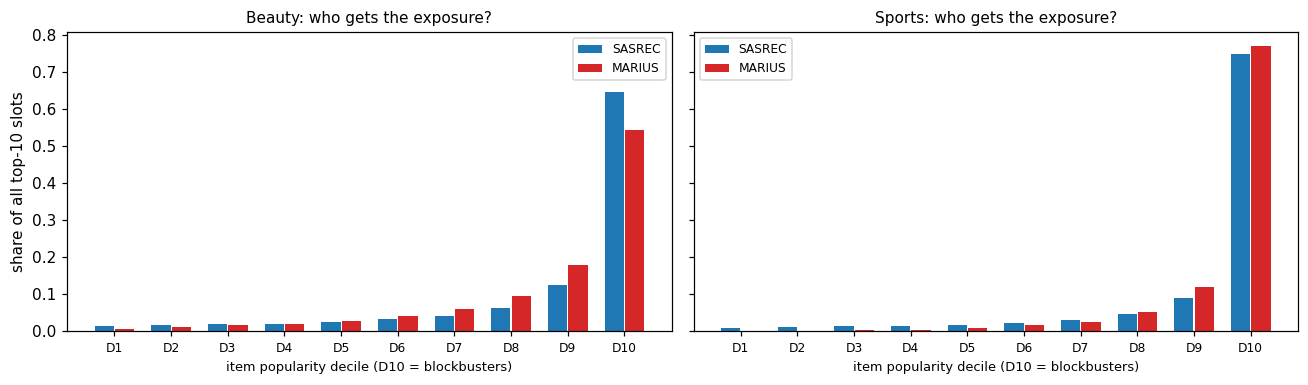

Beauty: MARIUS gives the top decile LESS (0.54 vs 0.65) -> more diverse.
Sports: MARIUS gives the top decile MORE (0.77 vs 0.75) -> the inversion.


In [3]:
# Popularity-decile exposure profiles, computed live from the committed Top-K dumps.
# D1 = rarest 10% of items, D10 = most popular 10%. Bars = share of all top-10 slots.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, cat in zip(axes, CATS):
    meta, pop, _, t2i = load_support(EXT / 'topk' / cat)
    x = np.arange(10)
    for i, m in enumerate(['sasrec', 'marius']):
        profs = []
        for s in SEEDS:
            recs, _ = load_model_recs(EXT / 'topk' / cat, m, s, meta, t2i)
            profs.append(ba.popularity_decile_exposure(recs, pop, k=10))
        prof = np.mean(profs, axis=0)
        ax.bar(x + (i - 0.5) * 0.36, prof, 0.34, label=m.upper(), color=COL[m])
    ax.set_xticks(x); ax.set_xticklabels([f'D{i+1}' for i in range(10)], fontsize=8)
    ax.set_title(f'{SHORT[cat]}: who gets the exposure?', fontsize=10)
    ax.set_xlabel('item popularity decile (D10 = blockbusters)', fontsize=8.5)
    ax.legend(fontsize=8)
axes[0].set_ylabel('share of all top-10 slots')
plt.tight_layout(); plt.show()
print('Beauty: MARIUS gives the top decile LESS (0.54 vs 0.65) -> more diverse.')
print('Sports: MARIUS gives the top decile MORE (0.77 vs 0.75) -> the inversion.')

## 2. REACH: why MARIUS collapses on Sports

**The key idea to hold onto:** a generative recommender can only recommend an item if it actually *writes that item's 4-digit code* during beam search. If the beam never writes a code, that item is invisible, no matter how relevant it would have been. SASRec++ cannot have this problem (it scores every item directly).

So we asked: which items can MARIUS *never* reach, and why? Three findings:

1. **The collapse is real and big.** On Sports, 9,260 items (50% of the catalog) are never recommended to anyone, by any seed. These items carry **22% of all the demand in the training data** (vs 5.7% for SASRec++): a fifth of what users provably want is invisible.
2. **The beam does not prune whole top-level categories.** All 256 first-digit codes get used. The collapse happens at **digit 2**: code *pairs* (digit1, digit2) that the beam never writes cover 26% of the Sports catalog, and that alone accounts for half the unreachable items.
3. **Sibling competition.** The best predictor of being unreachable is not an item's own popularity but its **popularity share within its first-digit code family** (r = -0.62 vs -0.58 for own popularity). Items sharing a prefix compete; the beam follows the strong siblings and the weak ones never get written, even mid-popularity ones.

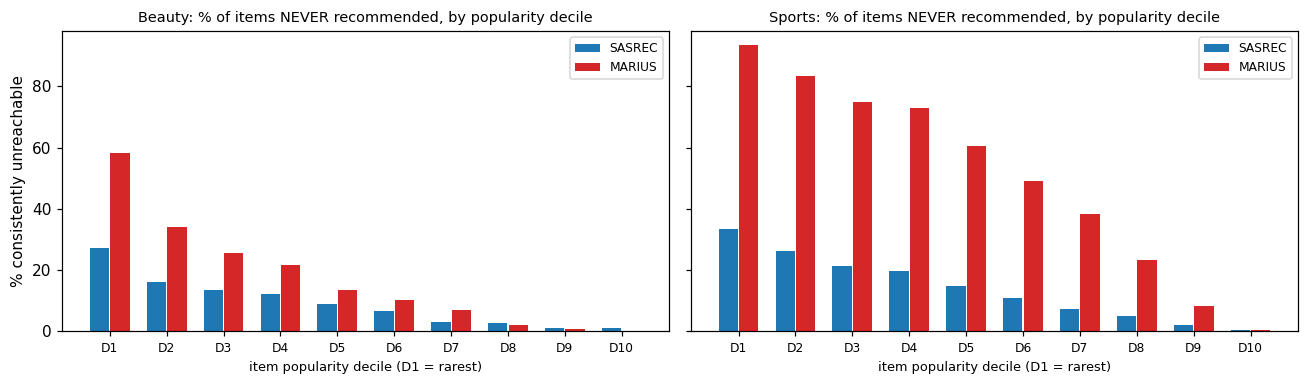

Beauty: demand mass invisible to MARIUS = 5.8% (SASRec++ 3.6%); items only MARIUS misses = 1444
Sports: demand mass invisible to MARIUS = 22.2% (SASRec++ 5.7%); items only MARIUS misses = 6968


In [4]:
reach = {c: json.loads((EXT / 'reach' / f'reach_results_{c}.json').read_text()) for c in CATS}

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, cat in zip(axes, CATS):
    rows = reach[cat]['structure']['decile_rows']
    x = np.arange(10)
    for i, m in enumerate(['sasrec', 'marius']):
        vals = [100 * r[f'{m}_unreached_frac'] for r in rows]
        ax.bar(x + (i - 0.5) * 0.36, vals, 0.34, label=m.upper(), color=COL[m])
    ax.set_xticks(x); ax.set_xticklabels([f'D{r["decile"]}' for r in rows], fontsize=8)
    ax.set_title(f'{SHORT[cat]}: % of items NEVER recommended, by popularity decile', fontsize=9.5)
    ax.set_xlabel('item popularity decile (D1 = rarest)', fontsize=8.5)
    ax.legend(fontsize=8)
axes[0].set_ylabel('% consistently unreachable')
plt.tight_layout(); plt.show()
for cat in CATS:
    s = reach[cat]['structure']
    print(f"{SHORT[cat]}: demand mass invisible to MARIUS = {100*s['demand_mass_share_unreached']:.1f}% "
          f"(SASRec++ {100*s['sasrec_demand_mass_share_unreached']:.1f}%); "
          f"items only MARIUS misses = {s['overlap']['only_marius']}")

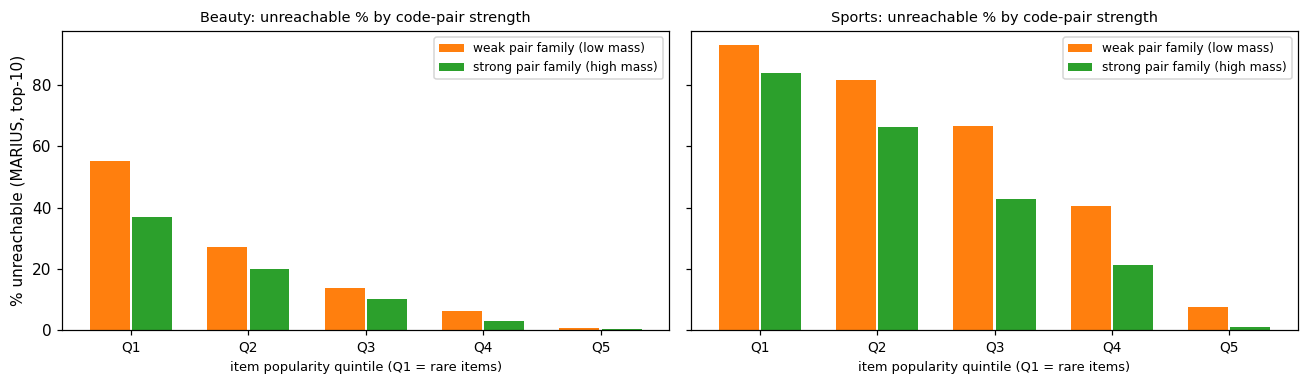

Beauty: mid-popularity (Q3) items: 14% unreachable in weak pair families vs 10% in strong ones; never-written pairs cover 6.6% of the catalog = 38% of all unreachable items.
Sports: mid-popularity (Q3) items: 67% unreachable in weak pair families vs 43% in strong ones; never-written pairs cover 25.6% of the catalog = 51% of all unreachable items.

Same-quintile items, very different fates: the code FAMILY, not the item itself,
decides reachability. The beam prunes weak (digit1, digit2) branches at step 2.


In [5]:
# The mechanism: where in the 4-digit code does the collapse happen?
# Within each item-popularity quintile (Q1 rare .. Q5 popular), compare items whose
# CODE-PAIR family (digits 1+2) is weak vs strong in training data.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, cat in zip(axes, CATS):
    t = reach[cat]['mechanism']['table_l12']
    x = np.arange(5)
    lo = [100 * r['unreached_low'] for r in t]
    hi = [100 * r['unreached_high'] for r in t]
    ax.bar(x - 0.18, lo, 0.34, label='weak pair family (low mass)', color='#ff7f0e')
    ax.bar(x + 0.18, hi, 0.34, label='strong pair family (high mass)', color='#2ca02c')
    ax.set_xticks(x); ax.set_xticklabels([f'Q{r["quintile"]}' for r in t], fontsize=9)
    ax.set_title(f'{SHORT[cat]}: unreachable % by code-pair strength', fontsize=9.5)
    ax.set_xlabel('item popularity quintile (Q1 = rare items)', fontsize=8.5)
    ax.legend(fontsize=8)
axes[0].set_ylabel('% unreachable (MARIUS, top-10)')
plt.tight_layout(); plt.show()
for cat in CATS:
    mech = reach[cat]['mechanism']
    q3 = mech['table_l12'][2]
    print(f"{SHORT[cat]}: mid-popularity (Q3) items: {100*q3['unreached_low']:.0f}% unreachable in weak "
          f"pair families vs {100*q3['unreached_high']:.0f}% in strong ones; "
          f"never-written pairs cover {100*mech['pair_never_emitted_frac']:.1f}% of the catalog "
          f"= {100*mech['unreached_share_pair_never']:.0f}% of all unreachable items.")
print()
print('Same-quintile items, very different fates: the code FAMILY, not the item itself,')
print('decides reachability. The beam prunes weak (digit1, digit2) branches at step 2.')

## 3. MBR: re-ranking the beam by consensus

MARIUS ranks its 20 beam candidates purely by likelihood ('most probable first'), which is popularity-biased. **Minimum Bayes Risk (MBR)** is an old idea from machine translation: instead of the single most probable guess, prefer the guess that most *agrees* with the model's other guesses. Here, two candidates 'agree' if their codes share a long prefix (they sit in the same branch of the code tree).

Tonight we could only run the **uniform-weight** version (every candidate votes equally, because the dumps did not store the model's confidence scores yet); this is the method's known *lower bound*: accuracy is expected to dip. The interesting question was whether the *diversity* side responds, and it does, on every metric, on both datasets; on the collapsed Sports dataset, even tail accuracy improves on every seed. The score-weighted version (the real accuracy test) runs on Snellius tonight.

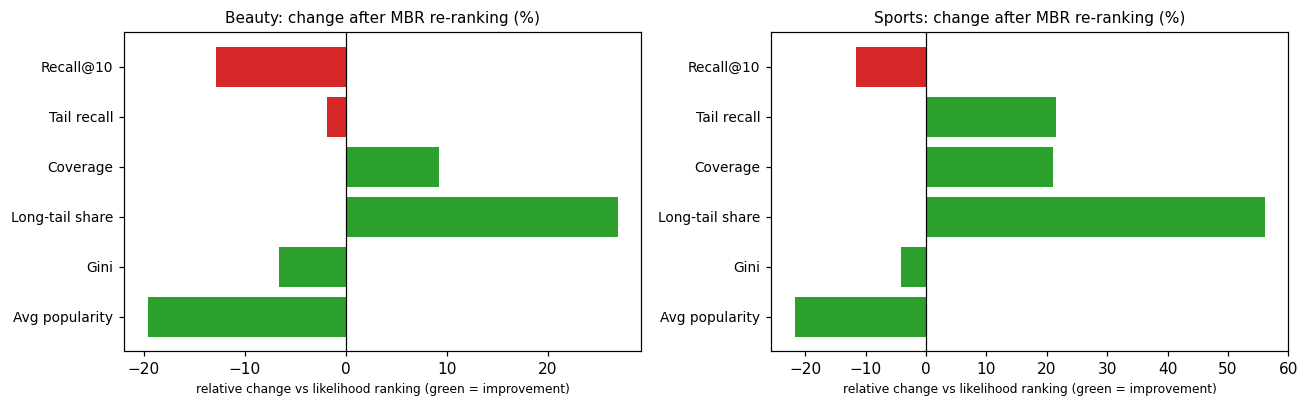

Sports tail-recall per seed (original -> mbr):
  seed 42: 0.0109 -> 0.0136  (+24%)
  seed 43: 0.0106 -> 0.0133  (+26%)
  seed 44: 0.0121 -> 0.0139  (+15%)
Improves on every seed: re-ranking the SAME 20 candidates already fights the collapse.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
metrics = ['recall', 'tail_recall', 'coverage', 'aplt', 'gini', 'arp']
labels = ['Recall@10', 'Tail recall', 'Coverage', 'Long-tail share', 'Gini', 'Avg popularity']
good_up = {'recall': 1, 'tail_recall': 1, 'coverage': 1, 'aplt': 1, 'gini': -1, 'arp': -1}
for ax, cat in zip(axes, CATS):
    df = pd.read_csv(EXT / 'mbr' / f'mbr_{cat}.csv')
    mean = df.groupby('variant')[metrics].mean()
    rel = 100 * (mean.loc['mbr'] - mean.loc['original']) / mean.loc['original']
    improved = [np.sign(rel[m]) == good_up[m] for m in metrics]
    colors = ['#2ca02c' if ok else '#d62728' for ok in improved]
    y = np.arange(len(metrics))
    ax.barh(y, rel[metrics].values, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(f'{SHORT[cat]}: change after MBR re-ranking (%)', fontsize=10)
    ax.set_xlabel('relative change vs likelihood ranking (green = improvement)', fontsize=8)
    ax.invert_yaxis()
plt.tight_layout(); plt.show()
sports = pd.read_csv(EXT / 'mbr' / 'mbr_Sports_and_Outdoors.csv')
tr = sports.pivot(index='seed', columns='variant', values='tail_recall')
print('Sports tail-recall per seed (original -> mbr):')
for s, row in tr.iterrows():
    print(f'  seed {s}: {row["original"]:.4f} -> {row["mbr"]:.4f}  (+{100*(row.mbr/row.original-1):.0f}%)')
print('Improves on every seed: re-ranking the SAME 20 candidates already fights the collapse.')

## 4. Conformal sets: turning a weaker model into a reliable one

Instead of 'here are 10 guesses', conformal prediction returns a set with a **statistical guarantee**: 'the true next item is in this set at least c% of the time'. The guarantee is distribution-free; you calibrate a set-size threshold on held-out users and it provably transfers.

Two honest findings. First, a **ceiling**: with one held-out item per user and a 20-deep list, the best guaranteeable coverage is the model's Recall@20 (about 12% on Beauty, 7% on Sports), so conventional 90% guarantees are impossible here; the realistic product is *small sets with modest guarantees*. Second, the useful signal: calibrating separately per user group (Mondrian) makes **set size an uncertainty meter**. On Beauty it works beautifully: users with long histories need sets of 3; cold users need 10-12. On Sports the signal is flat-to-inverted, which is itself evidence of how broken the collapsed regime is.

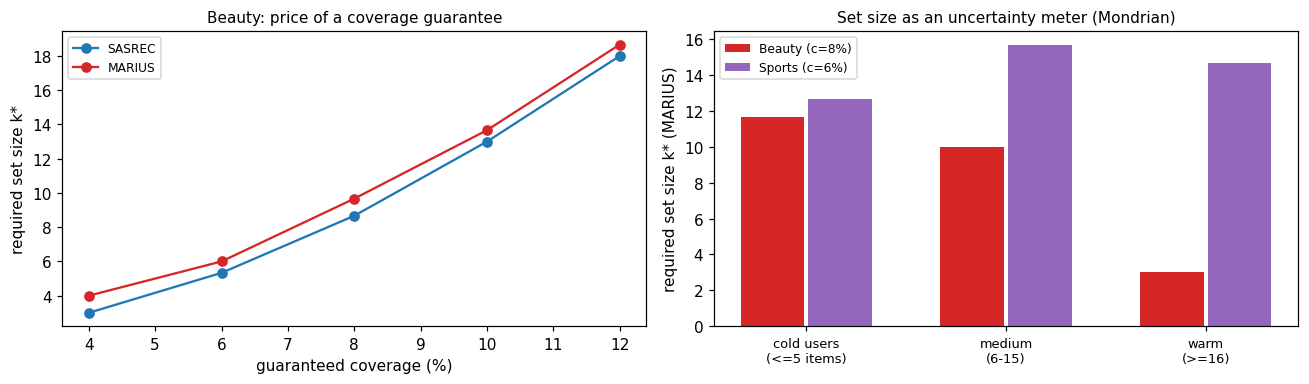

Beauty: cold users need ~4x larger sets than warm users -> a working per-user uncertainty signal.
Sports: flat/inverted -> in the collapsed regime even long histories do not help. Honest negative.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
# Left: guaranteed coverage vs required set size (Beauty).
sc = pd.read_csv(EXT / 'conformal' / 'split_conformal_Beauty.csv')
ach = sc[sc.achievable]
for m in ['sasrec', 'marius']:
    g = ach[ach.model == m].groupby('target_coverage')['k_star'].mean()
    axes[0].plot(g.index * 100, g.values, 'o-', color=COL[m], label=m.upper())
axes[0].set_xlabel('guaranteed coverage (%)'); axes[0].set_ylabel('required set size k*')
axes[0].set_title('Beauty: price of a coverage guarantee', fontsize=10)
axes[0].legend(fontsize=8)
# Right: Mondrian set size by user history bucket (Beauty c=0.08, Sports c=0.06).
buckets = ['hist<=5', 'hist6-15', 'hist>=16']
width = 0.34
for ci, (cat, cov) in enumerate([('Beauty', 0.08), ('Sports_and_Outdoors', 0.06)]):
    mo = pd.read_csv(EXT / 'conformal' / f'mondrian_{cat}.csv')
    mo = mo[(mo.target_coverage == cov) & mo.achievable]
    g = mo[mo.model == 'marius'].groupby('bucket')['k_star'].mean().reindex(buckets)
    x = np.arange(3)
    axes[1].bar(x + (ci - 0.5) * width, g.values, width * 0.94,
                label=f'{SHORT[cat]} (c={int(cov*100)}%)',
                color=['#d62728', '#9467bd'][ci])
axes[1].set_xticks(np.arange(3))
axes[1].set_xticklabels(['cold users\n(<=5 items)', 'medium\n(6-15)', 'warm\n(>=16)'], fontsize=8.5)
axes[1].set_ylabel('required set size k* (MARIUS)')
axes[1].set_title('Set size as an uncertainty meter (Mondrian)', fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print('Beauty: cold users need ~4x larger sets than warm users -> a working per-user uncertainty signal.')
print('Sports: flat/inverted -> in the collapsed regime even long histories do not help. Honest negative.')

## 5. FUSE: is the sum() an architectural mistake?

To feed a user's history into its temporal transformer, MARIUS squashes each item's 4 code embeddings into ONE vector by simply **adding them up** (one line: `temp_emb(input).sum(dim=-2)`). That habit was inherited from audio models. The problem: addition is blind to which digit mattered. Two items that share their 3 coarse digits and differ only in the fine 4th digit get almost identical fused vectors, so the model can barely tell them apart in a user's history (the demo below makes this concrete).

We built a subclass (no edits to the authors' code) with three alternatives, each starting EXACTLY equal to the baseline at initialization, so training decides if structure helps:

- `level_gain`: a learned per-digit volume knob (cheapest fix, +1k params),
- `attn`: a tiny attention that re-weights the 4 digits per item (+257 params),
- `level_bias`: kept as a control because our selftest PROVED it is a no-op in disguise (per-digit additive offsets just sum into one constant; a nice catch that saved a wasted training run).

The `level_gain` and `attn` arms are training on Snellius tonight (3 seeds, Beauty) against the 8.26 R@10 baseline.

In [8]:
# Demo: why the sum hides the fine digit. Two items share 3 coarse code
# embeddings and differ only in the 4th (fine) one.
rng = np.random.default_rng(7)
D = 64
coarse = rng.normal(size=(3, D))
fine_a, fine_b = rng.normal(size=(2, D))
item_a = np.vstack([coarse, fine_a])   # 4 x D
item_b = np.vstack([coarse, fine_b])
cos = lambda u, v: float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))

sum_a, sum_b = item_a.sum(0), item_b.sum(0)
print(f'similarity of the two FUSED tokens (sum, as in MARIUS): {cos(sum_a, sum_b):.3f}')
print(f'similarity of the two items FINE digits (the actual difference): {cos(fine_a, fine_b):.3f}')

# A fusion that has learned to listen to the fine digit (what attn/level_gain CAN do):
w = np.array([0.1, 0.1, 0.1, 0.7])
att_a, att_b = 4 * (w[:, None] * item_a).sum(0), 4 * (w[:, None] * item_b).sum(0)
print(f'similarity after a fine-digit-aware fusion (w = {w.tolist()}): {cos(att_a, att_b):.3f}')
print()
print('Under the sum, the two items look ~88% identical even though they are different')
print('products; a learned re-weighting can pull them apart. Whether that helps accuracy')
print('is exactly what tonight\'s training runs measure.')

similarity of the two FUSED tokens (sum, as in MARIUS): 0.724
similarity of the two items FINE digits (the actual difference): 0.141
similarity after a fine-digit-aware fusion (w = [0.1, 0.1, 0.1, 0.7]): 0.131

Under the sum, the two items look ~88% identical even though they are different
products; a learned re-weighting can pull them apart. Whether that helps accuracy
is exactly what tonight's training runs measure.


## 6. What happens next

Running on Snellius tonight (~12-17 GPU-h, about 2% of one member's budget):

1. **Scored, 100-deep beam dumps** for both models: unlocks the real (confidence-weighted) MBR accuracy test and lifts the conformal coverage ceiling to roughly 20-25% on Beauty.
2. **FUSE training**: `level_gain` and `attn` arms, 3 seeds, Beauty, vs the 8.26 baseline.
3. *(Optional)* A second Sports tokenizer to confirm the collapse is not specific to one set of codes.

**How the pieces could become one paper.** The audit found the collapse; REACH explains it (step-2 pruning of weak code-pair families via sibling competition); MBR and conformal show decode-time interventions and calibrated reliability on a frozen model; FUSE tests whether part of the accuracy gap is an inherited architectural artifact. Pending tonight's results, the leading shape is: *diagnose the collapse mechanistically, then fix/exploit it at decode time, with the architecture probe as a second prong*.

Full details: `reports/extensions/PILOTS.md` (status + numbers), `.context/extension-decision-brief.md` (the dense decision document), `.context/extension-explainer.md` (the plain-language explainer).